In [1]:

import os, sys
import tensorflow as tf
import numpy as np
import torch
import matplotlib.pyplot as plt

# Enable memory growth
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

import sys, os
sys.path.append(os.path.abspath('..'))

from config import Config
from scene_engine import setup_scene, setup_scene_with_positions
from channel_analyzer import compute_batch_paths, get_ofdm_channel
from GMM.gmtc_em import gmm_em_fit_fullcov, predict_modes
config = Config()



2026-07-29 04:40:03.363000: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


jitc_llvm_init(): LLVM API initialization failed ..


In [2]:

# Cell A1: Dense spatial grid generation
x_range = np.linspace(20, 80, 15)
y_range = np.linspace(-10, 70, 20)
grid_x, grid_y = np.meshgrid(x_range, y_range)
z_fixed = 1.5

grid_positions = np.stack(
    [grid_x.ravel(), grid_y.ravel(), np.full(grid_x.size, z_fixed)], axis=-1
)
print("Grid map positions:", grid_positions.shape)



Grid map positions: (300, 3)


In [3]:

# Cell A2: Channel extraction for grid
scene_map, bs_map, _, _ = setup_scene_with_positions(config, grid_positions)
paths_map = compute_batch_paths(scene_map, max_depth=2)
h_grid = get_ofdm_channel(paths_map, config)
print("Grid channel shape:", h_grid.shape)



Grid channel shape: (300, 600, 64)


I0000 00:00:1785300007.638406 1569831 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46168 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:81:00.0, compute capability: 8.9
I0000 00:00:1785300007.639784 1569831 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 46548 MB memory:  -> device: 1, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:c1:00.0, compute capability: 8.9
I0000 00:00:1785300007.641133 1569831 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 46548 MB memory:  -> device: 2, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:c2:00.0, compute capability: 8.9


In [4]:

# Cell A3: Train GMM on grid data
N_grid, N_sub, N_tx = h_grid.shape
sub_stride = 10
sub_idx = tf.range(0, N_sub, sub_stride)
h_map_train = tf.reshape(tf.gather(h_grid, sub_idx, axis=1), [-1, N_tx])

h_map_real = tf.concat([tf.math.real(h_map_train), tf.math.imag(h_map_train)], axis=-1)
Xt_map_raw = torch.from_numpy(h_map_real.numpy()).to(torch.float32)
Xt_map = torch.nan_to_num(Xt_map_raw, nan=0.0)

print(f"Training GMM with {Xt_map.shape[0]} samples...")
print(f"Contains NaN: {torch.isnan(Xt_map).any().item()}")
print(f"Max val: {Xt_map.max().item()}, Min val: {Xt_map.min().item()}")
K = 4
params_map = gmm_em_fit_fullcov(Xt_map, K=K, num_iter=100, eps=1e-5, seed=42, verbose=True)

import os
os.makedirs("output", exist_ok=True)
torch.save(params_map, f"output/gmm_spatial_dictionary_K{K}.pt")



Training GMM with 18000 samples...
Contains NaN: False
Max val: 1.693690299987793, Min val: -1.6970869302749634
[EM] it=000 ll=4247953.500
[EM] it=001 ll=5057996.000 dLL=810042.500
[EM] it=002 ll=5558400.500 dLL=500404.500
[EM] it=003 ll=5715151.500 dLL=156751.000
[EM] it=004 ll=5939393.000 dLL=224241.500


[EM] it=005 ll=6302727.500 dLL=363334.500


[EM] it=006 ll=6460010.500 dLL=157283.000
[EM] it=007 ll=6509878.500 dLL=49868.000
[EM] it=008 ll=6528352.000 dLL=18473.500
[EM] it=009 ll=6551698.000 dLL=23346.000
[EM] it=010 ll=6556904.000 dLL=5206.000
[EM] it=011 ll=6559123.500 dLL=2219.500


[EM] it=012 ll=6558927.000 dLL=-196.500


[EM] it=013 ll=6560491.000 dLL=1564.000
[EM] it=014 ll=6567093.500 dLL=6602.500
[EM] it=015 ll=6581238.000 dLL=14144.500
[EM] it=016 ll=6587456.000 dLL=6218.000
[EM] it=017 ll=6603048.000 dLL=15592.000
[EM] it=018 ll=6624118.500 dLL=21070.500


...

[EM] it=080 ll=6664186.000 dLL=52.000
[EM] it=081 ll=6664151.500 dLL=-34.500
[EM] it=082 ll=6664242.500 dLL=91.000
[EM] it=083 ll=6664134.000 dLL=-108.500
[EM] it=084 ll=6664186.000 dLL=52.000
[EM] it=085 ll=6664151.500 dLL=-34.500


[EM] it=086 ll=6664242.500 dLL=91.000
[EM] it=087 ll=6664134.000 dLL=-108.500


[EM] it=088 ll=6664186.000 dLL=52.000
[EM] it=089 ll=6664151.500 dLL=-34.500
[EM] it=090 ll=6664242.500 dLL=91.000
[EM] it=091 ll=6664134.000 dLL=-108.500
[EM] it=092 ll=6664186.000 dLL=52.000


[EM] it=093 ll=6664151.500 dLL=-34.500
[EM] it=094 ll=6664242.500 dLL=91.000


[EM] it=095 ll=6664134.000 dLL=-108.500
[EM] it=096 ll=6664186.000 dLL=52.000
[EM] it=097 ll=6664151.500 dLL=-34.500
[EM] it=098 ll=6664242.500 dLL=91.000
[EM] it=099 ll=6664134.000 dLL=-108.500


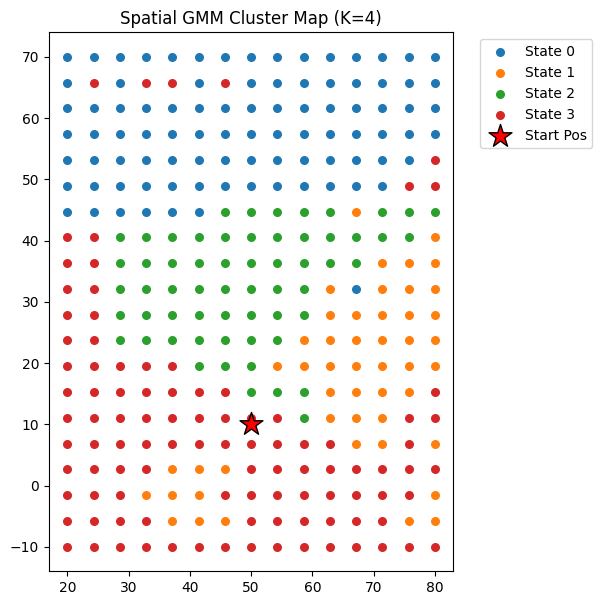

In [5]:

# Cell A4: Spatial EM Map visualization
sub_stride = 10
sub_idx = tf.range(0, N_sub, sub_stride)

h_grid_sub = tf.gather(h_grid, sub_idx, axis=1) # [N_grid, N_sub_sub, N_tx]
N_sub_sub = h_grid_sub.shape[1]

h_grid_sub_real = tf.concat([tf.math.real(h_grid_sub), tf.math.imag(h_grid_sub)], axis=-1)
h_grid_sub_torch = torch.nan_to_num(torch.from_numpy(h_grid_sub_real.numpy()).to(torch.float32), nan=0.0)

c_hat_grid_all = np.zeros((N_grid, N_sub_sub), dtype=int)
for i in range(N_sub_sub):
    c, _ = predict_modes(h_grid_sub_torch[:, i, :], params_map)
    c_hat_grid_all[:, i] = c.numpy()

from scipy.stats import mode
c_hat_grid, _ = mode(c_hat_grid_all, axis=1, keepdims=False)

cmap = plt.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(7, 7))
for k in range(K):
    m = (c_hat_grid == k)
    ax.scatter(grid_positions[m, 0], grid_positions[m, 1], s=30, color=cmap(k), label=f"State {k}")
ax.scatter(config.pos_start[0], config.pos_start[1], marker="*", s=300, c="red", edgecolor="k", label="Start Pos")
ax.set_title(f"Spatial GMM Cluster Map (K={K})")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_aspect("equal")
plt.savefig(f"output/em_map_spatial_K{K}.png", dpi=120, bbox_inches='tight')
plt.show()



In [6]:

# Cell B1: Load dictionary and query for trajectory
scene_traj, bs_traj, _, pos_tensor = setup_scene(config)
paths_traj = compute_batch_paths(scene_traj, max_depth=3)
h_traj = get_ofdm_channel(paths_traj, config)
print("Trajectory channel shape:", h_traj.shape)

h_traj_sub = tf.gather(h_traj, sub_idx, axis=1)
h_traj_sub_real = tf.concat([tf.math.real(h_traj_sub), tf.math.imag(h_traj_sub)], axis=-1)
h_traj_sub_torch = torch.nan_to_num(torch.from_numpy(h_traj_sub_real.numpy()).to(torch.float32), nan=0.0)

params_map = torch.load(f"output/gmm_spatial_dictionary_K{K}.pt", weights_only=False)

N_traj = h_traj.shape[0]
c_hat_traj_all = np.zeros((N_traj, N_sub_sub), dtype=int)
for i in range(N_sub_sub):
    c, _ = predict_modes(h_traj_sub_torch[:, i, :], params_map)
    c_hat_traj_all[:, i] = c.numpy()

c_hat_traj, _ = mode(c_hat_traj_all, axis=1, keepdims=False)

from collections import Counter
counts = Counter(c_hat_traj)
print("Trajectory State Counts:", counts)



Trajectory channel shape: (50, 600, 64)
Trajectory State Counts: Counter({2: 30, 0: 14, 3: 6})


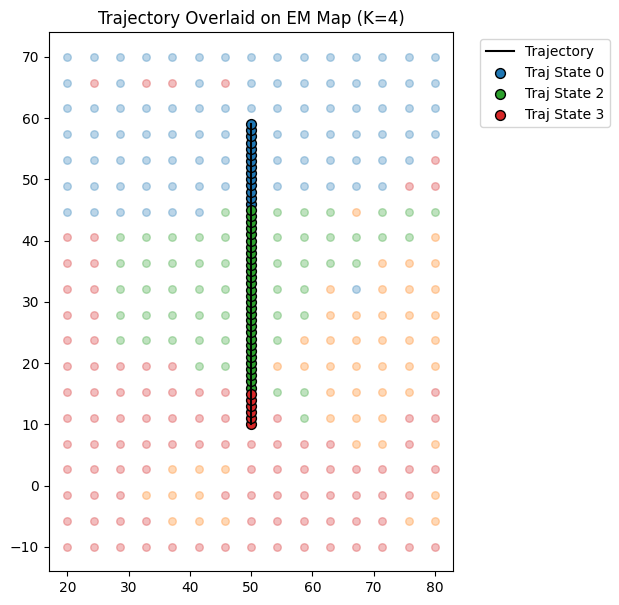

In [7]:

# Cell B2: Trajectory-overlaid EM map
fig, ax = plt.subplots(figsize=(7, 7))
for k in range(K):
    m = (c_hat_grid == k)
    ax.scatter(grid_positions[m, 0], grid_positions[m, 1], s=30, alpha=0.3, color=cmap(k))

traj_np = pos_tensor.numpy()
ax.plot(traj_np[:, 0], traj_np[:, 1], 'k-', label="Trajectory")
for k in range(K):
    m = (c_hat_traj == k)
    if np.any(m):
        ax.scatter(traj_np[m, 0], traj_np[m, 1], s=50, color=cmap(k), edgecolor='k', label=f"Traj State {k}")

ax.set_title(f"Trajectory Overlaid on EM Map (K={K})")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_aspect("equal")
plt.savefig(f"output/em_map_with_trajectory_K{K}.png", dpi=120, bbox_inches='tight')
plt.show()



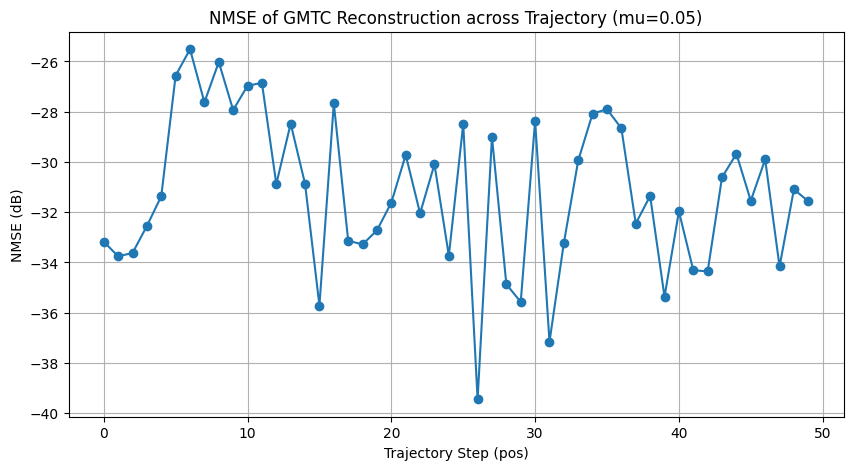

Average NMSE (dB): -31.22


In [8]:

# Cell B3: Re-validate GMTC Compression Pipeline
def reconstruct_complex_cov(R_real):
    N_t = R_real.shape[0] // 2
    R_xx = R_real[:N_t, :N_t]
    R_xy = R_real[:N_t, N_t:]
    return 2 * (R_xx - 1j * R_xy)

U_c_complex_list = []
lam_c_complex_list = []

for c in range(K):
    U_c_real = params_map.U[c].numpy()
    lam_c_real = params_map.lam[c].numpy()
    R_c_real = U_c_real @ np.diag(lam_c_real) @ U_c_real.T
    R_c_comp = reconstruct_complex_cov(R_c_real)
    
    evals, evecs = np.linalg.eigh(R_c_comp)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]
    
    lam_c_complex_list.append(evals)
    U_c_complex_list.append(evecs)

h_spatial_np = np.nan_to_num(h_traj[:, 300, :].numpy(), nan=0.0)
N_pos = h_spatial_np.shape[0]
h_hat = np.zeros_like(h_spatial_np)

mu = 0.05

for t in range(N_pos):
    c_hat_t = c_hat_traj[t].item()
    h_t = h_spatial_np[t]
    
    U_c = U_c_complex_list[c_hat_t]
    lam_c = lam_c_complex_list[c_hat_t]
    
    h_tilde = U_c.conj().T @ h_t
    mask = lam_c > mu
    h_tilde_q = h_tilde * mask
    
    h_hat[t] = U_c @ h_tilde_q

nmse_linear = np.sum(np.abs(h_spatial_np - h_hat)**2, axis=1) / np.sum(np.abs(h_spatial_np)**2, axis=1)
nmse_db = 10 * np.log10(nmse_linear + 1e-12)

plt.figure(figsize=(10, 5))
plt.plot(range(N_pos), nmse_db, marker="o", linestyle="-")
plt.title(f"NMSE of GMTC Reconstruction across Trajectory (mu={mu})")
plt.xlabel("Trajectory Step (pos)")
plt.ylabel("NMSE (dB)")
plt.grid(True)
plt.show()

print(f"Average NMSE (dB): {np.mean(nmse_db):.2f}")

